# Trying to explain ML models using local explainers: SHAP and LIME

In this post I want to explain how SHAP and LIME techniques works using [Mobile Price Classification dataset](https://www.kaggle.com/datasets/iabhishekofficial/mobile-price-classification), creating a model to classify phones price range and try to find an explanation about how models makes its predictions.

## SHAP
SHAP is a technique for explaining ML models using local instances, is based on games theory of shapley's values. This technique is model agnostic, so it doesn't care what model are you trying to explain, it can calculate an approximate value of the feature SHAP value.  
The approach is based on cooperative games theory where the question that motivated this solution was: "How can I measure the contribution of each player to the final result of a match?". From the original statement with can extend its scope to ML models, instead of players, we got data features.

### SHAP values
SHAP values are like the contribution measure of some feature to a model prediction. SHAP values capture the marginal contribution of each feature to the final prediction. In other words, is the impact of having a certain for a value given feature in comparison to the prediction we'd make if that feature took some baseline value.

### How does it works?
Technique works creating an approximation of SHAP values based on some data, it takes actual model output and a baseline output following this equallity:

<center>
    $\sum_{shap_value \in SHAP_values} = model output - pred for baseline values$
</center>

to calculate baseline values it requires data instances, and then perfoms a calculation for weighted mean average payoff gain that a single feature provides when included in all cases where is excluded, this is like asking "how many goals on average the team lose or win if we 'remove' Ronaldo or Messi in some soccer matches?".

### Procedure
1. Train a ML model.
2. Create a SHAP explainer instance using the model.
3. Calculate values SHAP values using **testing** or **validation datasets**.
4. Create some plots from SHAP values to explain model predictions.

In [1]:
from pandas import read_csv
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

data = read_csv("/kaggle/input/datasets/iabhishekofficial/mobile-price-classification/train.csv")
COL_MAPPER = {"fc": "front_camera_pixels", "four_g": "has_4g", "int_memory": "storage_size", 
              "mobile_wt": "weight", "m_dep": "depth_cm", "n_cores": "cpu_cores", "pc": "rear_camera_pixels",
              "px_width": "screen_width_pixels", "px_height": "screen_height_pixels", "sc_w": "screen_width_cm",
              "sc_h": "screen_height_cm", "three_g": "has_3g", "touch_screen": "has_touch_screen", "wifi": "has_wifi",
              "blue": "has_bluetooth", "clock_speed": "cpu_clock_speed"}

renamed_data = data.rename(columns=COL_MAPPER)

NUMS = ["battery_power","cpu_clock_speed", "depth_cm", "front_camera_pixels", "storage_size", "weight", "cpu_cores",
       "rear_camera_pixels", "screen_height_pixels","screen_width_pixels","ram","screen_height_cm","screen_width_cm","talk_time"]
BINS = ["has_4g", "has_3g", "has_bluetooth", "dual_sim", "has_wifi", "has_touch_screen"]
FEATURES = NUMS + BINS
TAG = "price_range"

x_train, x_test, y_train, y_test = train_test_split(renamed_data[FEATURES], renamed_data[TAG], train_size=0.8, random_state=123)

TRANSFORMER = ColumnTransformer([("normalized", StandardScaler(), NUMS)],
                                remainder="passthrough", # Unstransformed data is still into the dataframe
                                verbose_feature_names_out=False # Feature names are not changed after transforming
                               )

# Setting output as pandas dataframe
TRANSFORMER.set_output(transform="pandas")

X_train = TRANSFORMER.fit_transform(x_train)
X_test = TRANSFORMER.transform(x_test)

# Model definition
MODEL = RandomForestClassifier(random_state=123, n_estimators=3, max_depth=8, criterion="gini")
MODEL.fit(X_train, y_train)
y_pred = MODEL.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
f1Score = f1_score(y_test, y_pred, average="weighted")
print(f"Accuracy: {(accuracy*100):2f} %")
print(f"Weighted F1-Score: {(f1Score*100):2f} %")

Accuracy: 69.250000 %
Weighted F1-Score: 68.524685 %


So, the classifier is trained and ready to be used on `shap` library, so this is a multiclass problem, then SHAP values area going to be calculated for every class.  
We are using a random forest classifier, then we must use `TreeExplainer` from `shap` library.

### `shap` library
`shap` is a library for explainable AI that implements SHAPley values calculation and provides tools for plotting SHAP values. `shap` has explainers for image, text and tabular models.  

Explainers are objects that takes the model and data to calculate an approximation of SHAP values. Main explainer is described by `Explainer` class, of course, there are speciallized models to use different stategies to approximate SHAP values, for instance: `TreeExplainer` is a specific implementation that leverages on tree and ensembles of trees models architecture to make calculations faster. Other is `LinearExplainer` designed to be used on linear models like logistic regression.  

Once a explainer is instantiated, there are two ways to calculate SHAP values:
- **Generating an `Explanation` object:** This is the most common and confortable way, `Explanation` object works like and indexable list of objects (if many data instances were through). Contains information about expected values and other metadata useful for plotting

```python
from shap import TreeExplainer, initjs, summary_plot

# Enables plotting
initjs()
# Instanting SHAP model
shap_explainer = TreeExplainer(MODEL)

# Calculating SHAP values
# Note: Expected output values are not required
explanation = shap_explainer(X_test, y_test)

# Explanation shape is:
# First dimension denotates data instance
# Second is for features values (is String indexes)
# Third is for model output. For binary classification there would be one dimension for positive value (1), and other for negative (0)
# In multiclass contexts, there will be a dimension per class. The same works for multioutput models

# Plotting a scatter chart
scatter(explanation[:, "cpu_clock_speed", 0])
```

- **Using `shap_values` method:** Creates a numpy array with shap values for each instance, feature and output (if multioutput or multiclass model). Just contains SHAP values, expected values or data must be provided via explainer properties.

```python
from shap import TreeExplainer, initjs, summary_plot

# Enables plotting
initjs()
# Instanting SHAP model
shap_explainer = TreeExplainer(MODEL)

# Calculating SHAP values
# Note: Expected output values are not required
explanation = shap_explainer.shap_values(X_test, y_test)

# The resulting numpy array has the shape described before

violin(shap_values[:, :, 0], X_test, max_display=10)
```

Be careful, some plot requires explicitly an `Explanation` object while other can work with the numpy array and providing other features.

In [2]:
from shap import TreeExplainer, initjs, summary_plot, Explainer, datasets
from shap.plots import violin, waterfall, force, bar, scatter

initjs()
shap_explainer = TreeExplainer(MODEL)
shap_values = shap_explainer.shap_values(X_test, y_test)
explanation = shap_explainer(X_test, y_test)

In [3]:
# Testing dataset has 400 rows and contains 20 features, last dimension contains 4 elements because are 4 classes
shap_values.shape

(400, 20, 4)

### Plots
#### Violin plot (previously summary plot)
Shows the significance of feature values due to model classification for each instance.
- Each dot is a row instance.
- Color represents the feature value
- Y-axis is the regarding feature.
- X-axis is the respective SHAP value.

**This plot is designed to be used on dataset, not just in a single instance**.

In this case, positive SHAP values tell us how much each feature contributes to classify an instance in an specific class. For example, in the following chart, "ram" feature has been taken as the most important feature. Watching its values, we can detail that mobile phones with too small ram sizes are classified into the cheapest price category ('Category 0') and higher values are predicted in more expensive classes.

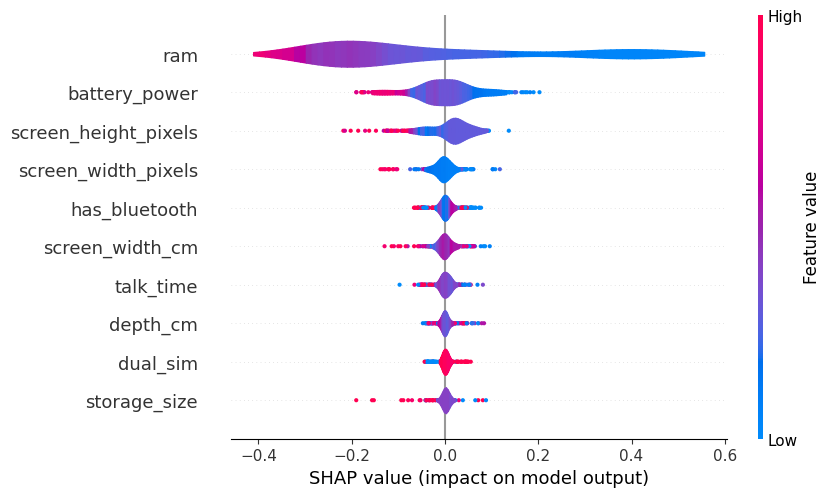

In [4]:
violin(shap_values[:, :, 0], X_test, max_display=10)

This is a summary plot using a bars instead of a violin plot, in the chart we can see how much a feature contributes to a model classification to each class. Keepp in mind that the chart is telling us which are the most important, not how does each feature impacts for a single class (negative or positive).

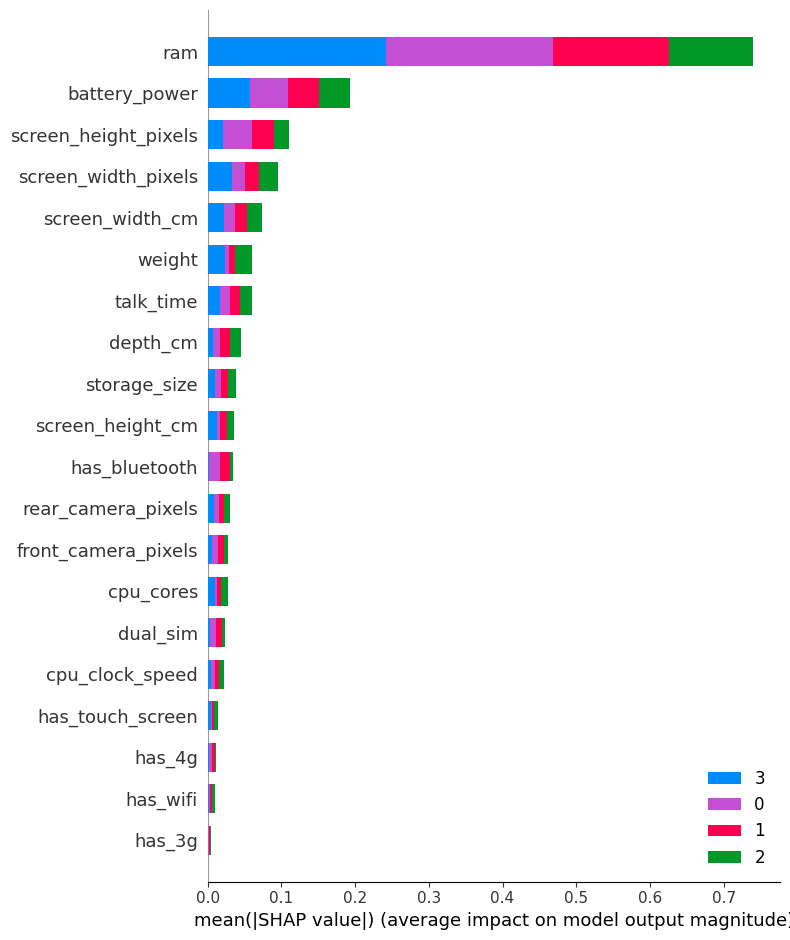

In [5]:
summary_plot(shap_values, X_test, plot_type="bar", class_names=MODEL.classes_, feature_names=X_test.columns)

#### Force plot
This plot is a summary of the previous, allow us to see how each attribute contibutes to a specific model predticion, for instance, in this case the expected value was 0.20 and instance belongs to class `1`, we see that `ram` attribute has the highest positive influence, so, we could say that is the strongest attribute to classify the instance at class 1. Also `cpu_scores` field is a weaker attribute, so we can state that hardware characteristics are the main features that the model bases its prediction.  
Negative SHAP values show that minor features like having bluetooth, screen resolution or camera have the strongest effect on telling the model "hey, this record doesn't belongs to price range '1'", however, ram effect is higher than 3 highest negative SHAP values.

In [6]:
force(shap_explainer.expected_value[1], shap_values[0, :, 1], X_train.columns)

Also we can check the behavior of more than 1 instance in a single chart to see trends or patterns about how the model classifies instances.
- X-axis shows instance ID.
- Y-axis are the SHAP values
- Lines represents attribute bounds.

Try to pass the mouse over chart on some different areas a you will check that legend changes when you move from an instance to another. Event, you can select a single attribute to be analyzed too.

In [7]:
# Watching SHAP values at class 1 on firsts 3 samples
force(shap_explainer.expected_value[1], shap_values[0:3, :, 1], X_train.columns)

#### Waterfall plot
Designed to explain a single instance, it shows the expected value (X-axis) compared with the real value (Y-axis), each row is a feature contribution to the final prediction, beign positive contributions red and negatives blue. With this chart you can see how baseline value moves to achieve target $Y$ value.

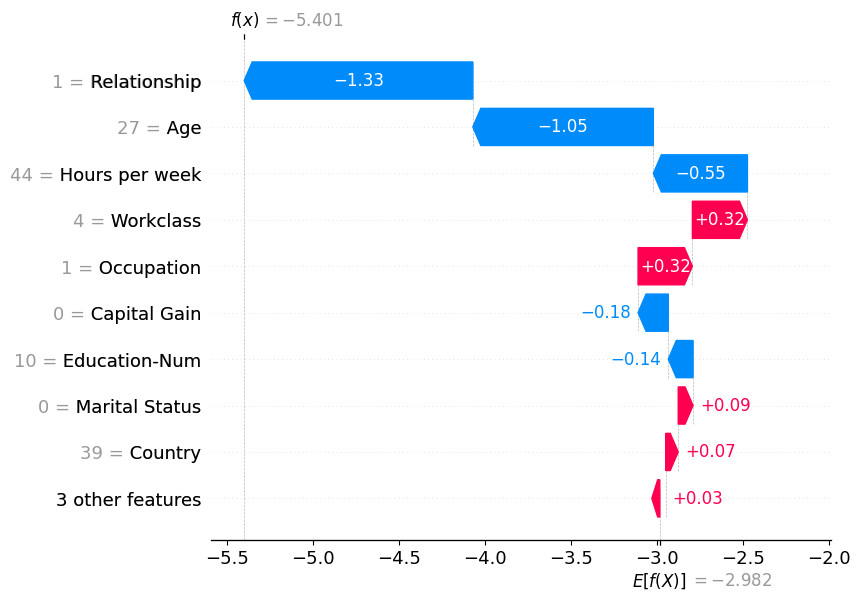

In [8]:
from xgboost import XGBClassifier

X, y = datasets.adult(n_points=2000)
OTHER_MODEL = XGBClassifier().fit(X, y)

# compute SHAP values
explainer = Explainer(OTHER_MODEL, X)
SHAP_VALUES = explainer(X)

waterfall(SHAP_VALUES[0])

#### Bar plot
Shows the importance of each feature from calculating the absolute mean of SHAP values.

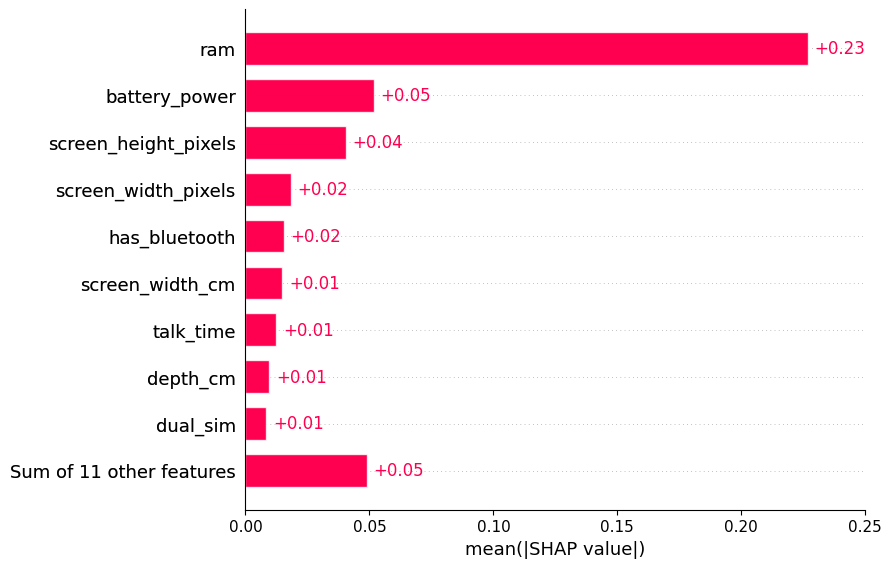

In [9]:
bar(explanation[:,:,0])

When a single instance is passed, a local explanation transforms plot shape like a waterfall plot, but X-axis shows SHAP values instead of expected values. As force and violin plots, just explains one class at once.

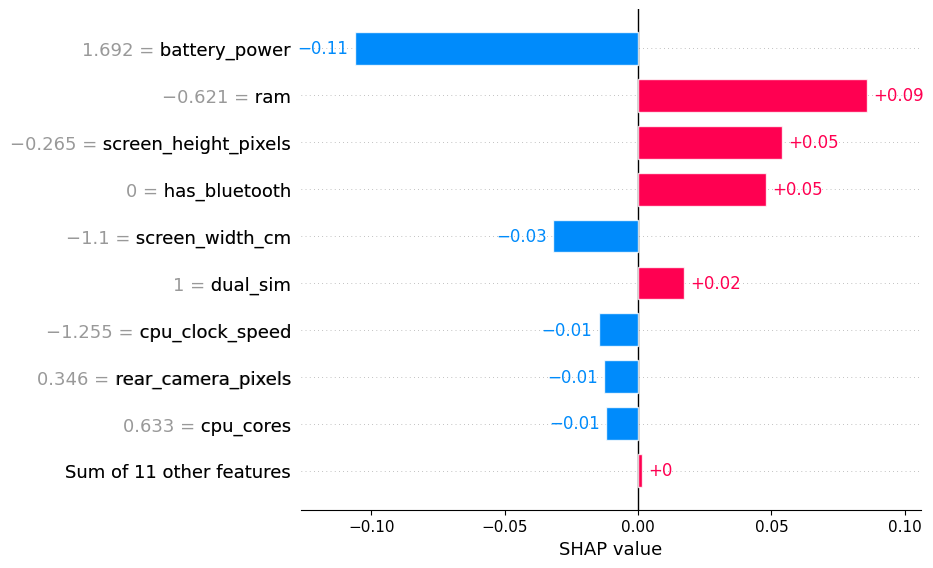

In [10]:
bar(explanation[0,:,0])

#### Dependence contribution/scatter plot
Works like a simple scatter plot linking a feature with its SHAP value for each data instance.
- X-axis is the value of the feature
- Y-axis is the SHAP value for the feature
- The plot shows a small histogram at the bottom representing the values distribution.

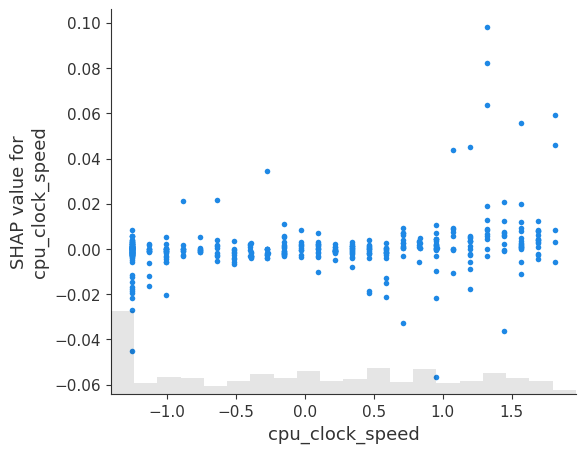

In [11]:
# Looking for patterns in class "0" on "cpu_clock_speed" attribute
scatter(explanation[:, "cpu_clock_speed", 0])

Also we can add a feature to assess interactions with out main feature creating a plot similar to a heatmap. `shap` tries to select the attribute with most effect on the studying variable, but we can define an attribute manually.

**Automatic attribute selection:**

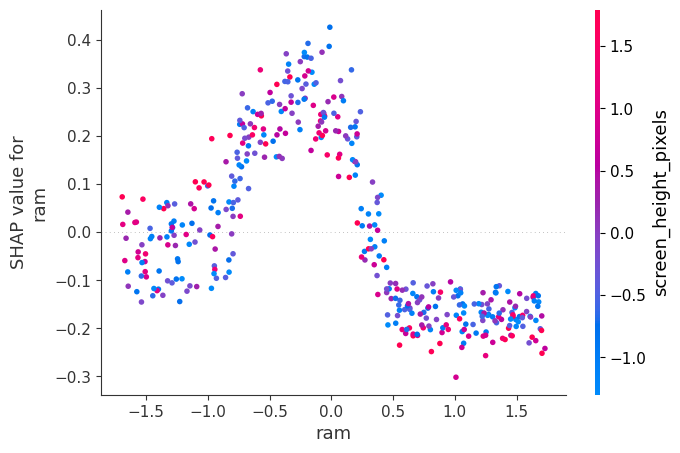

In [12]:
# Looking for patterns in "ram" attribute and an undefined linked field
scatter(explanation[:, "ram", 1], explanation[:, :, 1], hist=False)

**Manual attribute selection:**

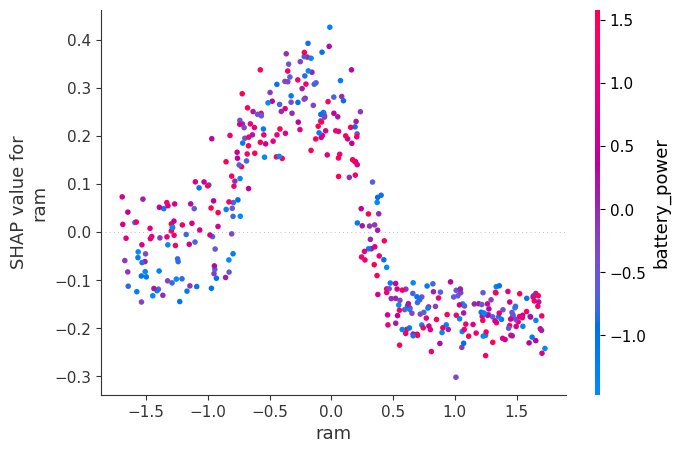

In [13]:
scatter(explanation[:, "ram", 1], explanation[:, "battery_power", 1], hist=False)

## LIME
Local interpretable model agnostic explanation (LIME) is an approach to make local explations about single data instances. While SHAP calculates shapley values, LIME uses a simple model (like linear regression) to estimate feature's significance.

### How does it works?
LIME tries to generate perturbed noisy data from the provided instance and uses the ML model to generate outcomes, from those results, try to create a simple model to explain the outcome on the original instance. LIME values works as SHAP values, so positive values tells  the contribution on the instance to be classified in the current class and negative values are the opposite.

### Tradeoffs
Thus, LIME is faster than SHAP, but its explanations are less consistent and weak, because that simple explanation model can not adapt complex model behaviors. For this reason, on scientific papers is common watching SHAP to explain model's behavior because can provide a reliable, consistent and local or global explanation about the model.

### When to use?
LIME is useful when you want to deploy a web application using a ML model and provide a simple way to explain model's outcomes. SHAP is more accurate but is too slow depending on the model and the approximation method, so LIME is a good choice.

### Procedure
1. Train a ML model.
2. Create a LIME explainer (specifying task and ML model training data).
3. Explain an instance specifying how many perturbed instances must create and the prediction function.

### `lime` package
`lime` package is the Python implementation for LIME algorithm, works like `shap`, but cutts off plotting API because this is a local explainer. As `shap`, available explainers are:
- **`LimeTabularExplainer`:** For classical ML troubles on tabular data.
- **`LimeTextExplainer`:** For text classifications.
- **`LimeImageExplainer`:** For image classification.
- **`LimeRecurrentTabularExplainer`:** For recurrent neural network models, designed to be used on time series.

To generate an explanation just call `explain_instance` method and library is going to perform model calculations and generate an explanation that can be seen in a Jupyter notebook environment, as an HTML file, as a pyplot chart or as python objects (list o map).

In [14]:
from lime.lime_tabular import LimeTabularExplainer

LIME_EXPLAINER = LimeTabularExplainer(
    X_train.to_numpy(),
    feature_names=FEATURES,
    mode="classification",
    categorical_features=[i for i in range(14,21)],
    class_names=[f"Price range {i}" for i in range(4)],
    random_state=123)


# In classsification problems, "predict_proba" is fine and for regression, "predict" method is enough
LIME_EXPLANATION = LIME_EXPLAINER.explain_instance(X_test.iloc[0],
                                                  MODEL.predict_proba,
                                                  num_samples=3000)

/usr/local/lib/python3.12/dist-packages/lime/discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.12/dist-packages/lime/discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.12/dist-packages/lime/lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.

Explanation as a list:
 [('-0.85 < ram <= 0.01', 0.339991996429154), ('-0.01 < screen_width_pixels <= 0.89', -0.022475059470341546), ('has_bluetooth=0', -0.019891564602520635), ('-0.82 < screen_height_pixels <= -0.18', -0.017670257404859377), ('screen_width_cm <= -0.87', 0.0156724187618243), ('dual_sim=1', -0.0144635147074166), ('has_4g=0', -0.01211125111496125), ('has_touch_screen=0', -0.007927520124279218), ('-0.23 < cpu_cores <= 1.07', -0.007061802141390913), ('talk_time > 0.91', 0.00644044155254072)] 

Explanation as figure:



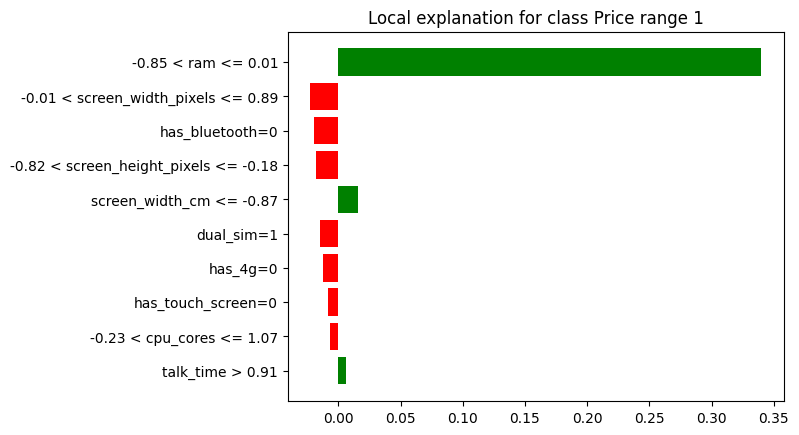

In [15]:
print("Explanation as a list:\n",LIME_EXPLANATION.as_list(),"\n")
print("Explanation as figure:\n")
LIME_EXPLANATION.as_pyplot_figure().show()

In [16]:
# Generates the HTML output of "as_html" method and renders it
# Probabilities comes from "predict_proba" method
LIME_EXPLANATION.show_in_notebook()